In [48]:
from copy import deepcopy as cp
from tqdm import tqdm
import numpy as np
import pandas as pd
import codecs
import re

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay
from experimental.display import create_tsne_for_plot
from experimental.metrics import bcb_clust

## Загрузка датасета

In [50]:
df = pd.read_pickle("statistics_and_text.pkl")
tlen = [len(elm) for elm in df["textInFile"]]
df["tlen"] = tlen
df = df[df["tlen"] > 100]

df = df[df['textInFile'].str.contains('УДК')]
n_pos_s = list(df['textInFile'].str.find('УДК'))

udk = []
udk2 = []
udk3 = []
udk31 = []
i = 0
for tx in tqdm(df['textInFile']):
    
    end = tx.find("\n", n_pos_s[i]+4)
    # print(tx[n_pos_s[i]+4:end])
    tx2 = tx[n_pos_s[i]+4:end].strip().replace("�", "-").replace("\t", ";").replace(" ", ";").replace(",", ";").replace("+", ";").replace(":", ";").replace("00", "0").replace(".", "")
    tx2 = re.sub("\([\w;.]+\)", "",tx2)
    tx2 = re.sub("[ ]+", " ",tx2)
    tx2 = tx2.replace(" - ", "-").split(";")
    tx2 = [tx_ for tx_ in tx2 if tx_ != "" and any(c.isalpha() for c in tx_) is False and len(tx_) < 25 and "�" not in tx_ and "?" not in tx_]
    #print(tx2)
    udk2_ = []
    udk2_2 = []
    
    for t in tx2:
        try:
            if t[:2] in ['01', '02', '04', '05', '06', '07', '30', '31', '32', '33', '34',
        '35', '36', '37', '50', '51', '52', '53', '54', '55', '57', '61',
        '62', '63', '65', '66', '68']:
                udk2_.append(t[:2])
                udk2_2.append(t[0])
        except:
            continue
    udk.append(np.unique(udk2_).tolist())
    udk3.append("".join(np.unique(udk2_).tolist()))
    udk31.append("".join(np.unique(udk2_2).tolist()))
    # print(udk[-1])
    udk2.append(len(udk[-1]))
    i += 1

df["УДК"] = udk
df["УДК-sp1"] = udk3
df["УДК-sp2"] = udk31
df["УДК-ln"] = udk2
print(len(df["textInFile"]))
df = df[df["УДК-ln"] != 0]
print(len(df["textInFile"]))
good_texts = []

100%|██████████| 4350/4350 [00:00<00:00, 16111.47it/s]

4350
4246


## Предобработка

1. Добавить проверку на то, что перед нами слова русского языка (а не рандомные наборы букв, такое бывает)

In [51]:
all_texts = list(df["textInFile"])
all_udcc = [int(elm[0]) for elm in list(df["УДК-sp2"])]

In [52]:
np.random.seed(0)
selection_ids = np.random.choice(len(all_texts), 500, replace=False, )
all_texts = [all_texts[i] for i in selection_ids]
all_udcc = [all_udcc[i] for i in selection_ids]

In [53]:
## удаление лишних символов, удаление необрабатываемых символов, удаление слишком коротких текстов.

red_texts = []
red_udcc = []
for i in tqdm(range(len(all_texts))):
    rt = all_texts[i].replace('-\n', '')
    rt = rt.replace('\n', ' ')
    rt = re.sub(r'[^а-яё.,:()\[\]0-9А-Я]', ' ', rt)
    # rt = re.sub(r'\s[а-яё.,:()0-9А-Я]\s', ' ', rt)
    rt = rt.replace(' . ', ' ')
    rt = re.sub('\s+', ' ', rt)
    rt = rt.split('.')
    rt = '. '.join([elm.strip() for elm in rt if elm.strip() !=''])
    if(len(rt) > 300):
        if red_texts != [] and red_texts[-1] == rt:
            continue
        red_texts.append(rt)
        red_udcc.append(all_udcc[i])

100%|██████████| 500/500 [00:08<00:00, 61.00it/s] 


In [54]:
## Разделение текстов на фрагменты (предложения). Удаление слишком длинных предложений
split_texts = []
for cur_text in tqdm(red_texts):
    split_text = []
    join_next = False
    keywords_rem = False
    cnt = -1
    ps = None
    
    for sent in re.split(r'([а-яё]\. )', cur_text):
        cnt += 1
        if cnt % 2 != 0:
            sent = ps + sent[:-2]
        else:
            ps = cp(sent)
            continue


        # останавливаемся, если дошли до списка литературы
        if re.search('список литературы', sent.lower()) is not None: 
            break
        
        if len(sent) > 1000:
            continue
        if len(sent) < 30:
            continue
        
        # убираем предложения, где слишком много больших букв
        if len(re.findall(r'[А-ЯЁ]', sent))/len(sent) > 0.5:
            continue
        # убираем предложения, где слишком много цифр
        if len(re.findall(r'[0-9()[]]', sent))/len(sent) > 0.5:
            continue
        # убираем предложения, где все слова начинаются с большой буквы
        if len(re.findall(r'[А-ЯЁ]', sent)) >= len(sent.split(' ')):
            continue
        # убираем предложение с ключевыми словами (но лишь раз)
        if re.search('ключевые слова', sent.lower()) is not None and not keywords_rem: 
            keywords_rem = True
            continue

        ## убираем последовательности цифр
        sent = re.sub(r'\b(?:[\d.,:()\[\]]\s*){4,}\d\b', '', sent)
        ## убираем последовательности больших букв
        sent = re.sub(r'\b(?:[А-ЯЁ]\s*){4,}\b', '', sent)

        
        if join_next:
            # print("joining")
            split_text[-1] = split_text[-1] + " " + sent
            join_next = False
            continue

        # if len(sent) < 100:
        #     join_next = True
        #     split_text.append(sent)
        #     continue       

        # про несправедливые разбиения
        if (not re.search("рис$",sent.lower()) is None) or (not re.search("табл$",sent.lower()) is None):
            # print("will join")
            join_next = True
            split_text.append(sent)
            continue
        
        # print("adding")
        split_text.append(sent)
    # for i in (split_text):
    #     print(i)
    split_texts.append(split_text)

100%|██████████| 500/500 [00:08<00:00, 57.40it/s]


In [55]:
split_texts[2]

['Аннотация: В рамках анизотропийной теории управления (. ,. ,. ) обращение средней анизотропийной нормы системы в нуль соответствует 2 теории, а обращение в бесконечность При этом естественным образом возникает вопрос, с какого значения анизотропийной нормы ее следует считать близкой к нулю или близкой к бесконечности, а какие значения не близки ни к нулю, ни к бесконечности',
 'В настоящей работе предлагается метод построения нормированной (то есть принимающей значения в единичном интервале) анизотропийной нормы случайного вектора как выбор соответствующего отображения положительной полуоси в единичный интервал',
 'В основополагающей работе [1] введены анизотропийные нормы случайного вектора и линейных систем',
 'Как следствие, были получены многочисленные значимые результаты в соответствующей области теории управления, например [2 11]. Цель исследований [1 11] объединить в рамках единого подхода к теории оптимального управления особенности как 2 , так и методов, основанных на 2 и но

## Сегментация

#### Разделение на сегменты

In [56]:
# segment split model (1).
# В начале сегментируем какой-нибудь существующей моделью (скажем, texttiling)
# На вход идет текст, битый по предложениям, на выходе текст, битый по сегментам.
from experimental.segmentation import simple_segmentation_sentences
from experimental.segmentation import text_tiling_segmentation
from experimental.segmentation import segment_with_graphs

In [57]:
segmented_texts = []
for split_text in tqdm(split_texts):
    segmented_texts.append(simple_segmentation_sentences(split_text))

100%|██████████| 500/500 [00:00<00:00, 499678.82it/s]


##### Нормализация и сохранение нормализованных текстов

In [58]:
from pymorphy3 import MorphAnalyzer
morph = MorphAnalyzer()

def pymorphy_parse_text(text):
    p_text = []
    for sent in text:
        p_text.append(' '.join([morph.parse(word)[0].normal_form for word in sent.split(' ')]))
    return p_text

In [59]:
# split_texts_normalized = []
# for text in tqdm(split_texts):
#     split_texts_normalized.append(pymorphy_parse_text(text))

In [60]:
from experimental.dset_loadings import create_and_save_dataframe
from experimental.dset_loadings import load_and_parse_dataframe

In [61]:
# create_and_save_dataframe(split_texts, split_texts_normalized, all_udcc)
split_texts, split_texts_normalized, all_udcc = load_and_parse_dataframe()

In [ ]:
# segmented_texts = []
# for split_text, split_text_normalized in tqdm(list(zip(split_texts,split_texts_normalized))):
#     segmented_texts.append(text_tiling_segmentation(split_text, split_text_normalized))

segmented_texts = []
for split_text, split_text_normalized in tqdm(list(zip(split_texts,split_texts_normalized))):
    if len(split_text) > 0:
        segmented_texts.append(segment_with_graphs(split_text, split_text_normalized))
    else:
        segmented_texts.append([])

#### Классификация сегментов

In [63]:
from similarity_module.similarity_measure.paper_similarity import get_sentence_embedding
from similarity_module.similarity_measure.paper_similarity import calculate_text_similarities
from similarity_module.segmentation_models.paper_segmentation_model import text_segment_classifier

In [64]:
# segment_model = text_segment_classifier("similarity_module/segmentation_models/full_model_segmentation_0.74_.wt", only_cpu= True)
segment_model = text_segment_classifier("similarity_module/segmentation_models/full_model_segmentation_d2_0.5.wt", only_cpu= True)
LabtoNum = {'None' : 0 , 'Resl' : 1, 'Obl' : 2, 'Goal' : 3, 'Algo' : 4}
NumToLab = { 0 : 'None', 1 : 'Resl', 2 : 'Obl', 3 : 'Goal', 4 : 'Algo'}
segment_model.pipeline.model.config.id2label = NumToLab
segment_model.pipeline.model.config.label2id = LabtoNum


loading base model...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mlsa-iai-msu-lab/sci-rus-tiny3 and are newly initialized: ['classifier.dense.weight', 'classifier.out_proj.weight', 'classifier.dense.bias', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


reconfiguring classifier head...
loading new weights...
done!


In [65]:
print(segment_model.pipeline.model.config.id2label)
print(segment_model.pipeline.model.config.label2id)

{0: 'None', 1: 'Resl', 2: 'Obl', 3: 'Goal', 4: 'Algo'}
{'None': 0, 'Resl': 1, 'Obl': 2, 'Goal': 3, 'Algo': 4}


In [66]:
# all_text_segmented = []
# i = 0
# for text in tqdm(segmented_texts):
#     i += 1 
#     text_dict = {}
#     if len(text) != 0:
#         preds = segment_model.mass_predict(text, verbal = False)
#         # print(preds)
#         # break
#         for i in range(len(preds)):
#             text_dict.setdefault(preds[i],[])
#             text_dict[preds[i]].append(text[i])
#         # for tag in text_dict:
#         #     print(len(text_dict[tag]))
#         # print()
#     all_text_segmented.append(text_dict)

In [ ]:
# # это вариант для двухклассового разбиения на "правильный текст" и "неправильный текст"
# all_text_segmented = []
# i = 0
# for text in tqdm(segmented_texts):
#     i += 1 
#     text_dict = {}
#     if len(text) != 0:
#         preds = segment_model.mass_predict(text, verbal = False)
#         # print(preds)
#         # break
#         for i in range(len(preds)):
#             if preds[i] == 'None':
#                 text_dict.setdefault(preds[i],[])
#                 text_dict[preds[i]].append(text[i])
#             else:
#                 text_dict.setdefault('Algo',[])
#                 text_dict['Algo'].append(text[i])
#         # for tag in text_dict:
#         #     print(len(text_dict[tag]))
#         # print()
#     # print([[k, len(text_dict[k])] for k in text_dict.keys()])
#     all_text_segmented.append(text_dict)

100%|██████████| 500/500 [27:42<00:00,  3.32s/it]  


In [81]:
all_text_segmented = []
i = 0
for text in tqdm(segmented_texts):
    i += 1 
    text_dict = {}
    if len(text) != 0:
        text_dict = segment_model.mass_predict_alter(text, verbal = False, n_samples = 5, unique = False)
        # # print(preds)
        # # break
        # for i in range(len(preds)):
        #     text_dict.setdefault(preds[i],[])
        #     text_dict[preds[i]].append(text[i])
        # # for tag in text_dict:
        # #     print(len(text_dict[tag]))
        # # print()
    all_text_segmented.append(text_dict)

100%|██████████| 500/500 [18:02<00:00,  2.17s/it]  


In [99]:
wk = all_text_segmented[4]
for key in wk.keys():
    if key != "None":
        print(key)
        for elm in wk[key]:
            print(elm)

Algo
Возможность прогнозирования объемов образования отходов электронного и электрического оборудования на выбранной территории
Разработка и апробация методики прогнозирования объемов образования электронных отходов на уровне отдельных территорий на основе открытых данных, публикуемых Росстатом
Использованы методы проектного анализа, анализа временных рядов, а также методика Партнерства в области Глобальной статистики электронных отходов ( ). Результаты
Получен прогноз по объемам образования электронных отходов для 10 регионов Российской Федерации, оценен потенциал создания новых рабочих мест в сфере переработки электронных отходов для каждого из рассмотренных регионов
Уточнение результатов прогноза возможно за счет проведения эмпирических исследований для идентификации изменений в потребительском поведении российских граждан в ответ на изменение экономической ситуации и возникновение проблем с доступностью ряда электронных товаров
 Для цитирования: Ратнер С. В. , Багаева Д. М. Методол

## Векторизация

In [100]:
available_tags = list(segment_model.pipeline.model.config.label2id.keys())

In [101]:
all_text_vectorized = []
for text in tqdm(all_text_segmented):
    elm_dict = {tag : None for tag in available_tags}
    for tag in text:
        elm_dict[tag] = np.array([get_sentence_embedding(sent) for sent in text[tag]])
    all_text_vectorized.append(elm_dict)

100%|██████████| 500/500 [40:06<00:00,  4.81s/it]  


## Измерение близости

In [102]:
from sklearn.metrics.pairwise import cosine_similarity
def ot_text_sim_func(lhs_vectors, rhs_vectors):
    return cosine_similarity(lhs_vectors, rhs_vectors)

In [103]:
for i in range(len(all_text_vectorized)):
    torm = []
    for elm in all_text_vectorized[i]:
        if all_text_vectorized[i][elm] is not None:
            if len(all_text_vectorized[i][elm]) == 0:
                torm.append(elm)
    for elm in torm:
        all_text_vectorized[i].pop(elm)

In [104]:
text_similarities_matrix = np.zeros((len(all_text_vectorized), len(all_text_vectorized), len(available_tags[:])))
for i in tqdm(range(len(all_text_vectorized))):
    for j in range(i, len(all_text_vectorized)):
        t_sims = calculate_text_similarities(all_text_vectorized[i], all_text_vectorized[j], compare_sentences = True, selection_method = 5, comparation_method=ot_text_sim_func)
        text_similarities_matrix[i][j] = np.array(list(t_sims.values())[:])
## заполняем вторую половину матрицы
for i in range(len(text_similarities_matrix)):
    for j in range(0,i):
        text_similarities_matrix[i,j] = text_similarities_matrix[j,i]

100%|██████████| 500/500 [06:48<00:00,  1.22it/s]


In [105]:
available_tags

['None', 'Resl', 'Obl', 'Goal', 'Algo']

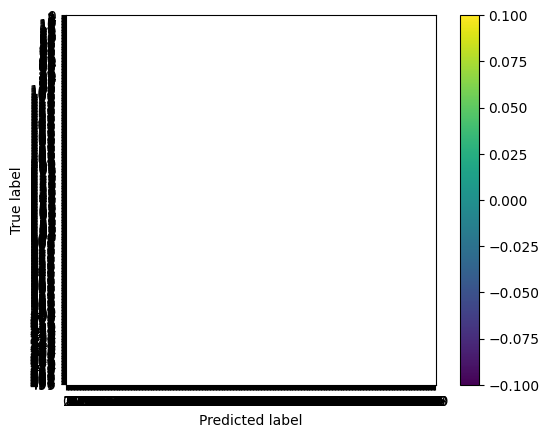

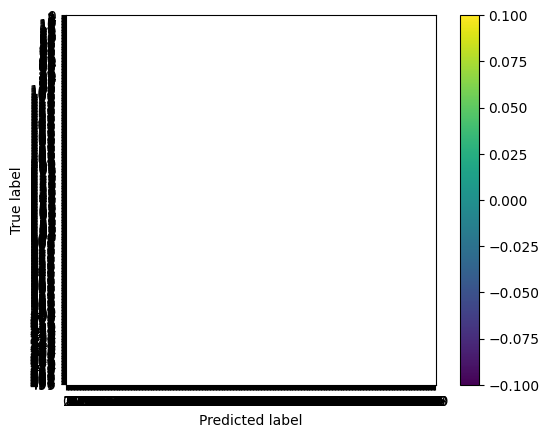

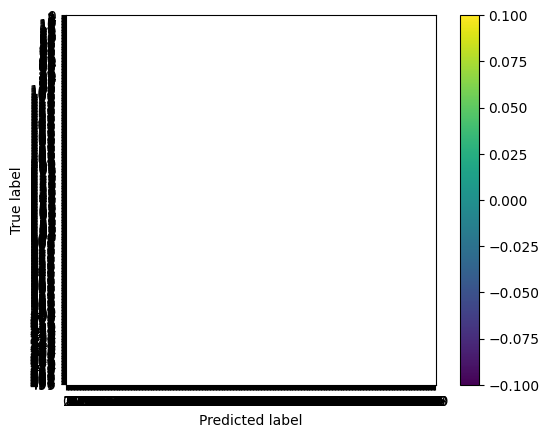

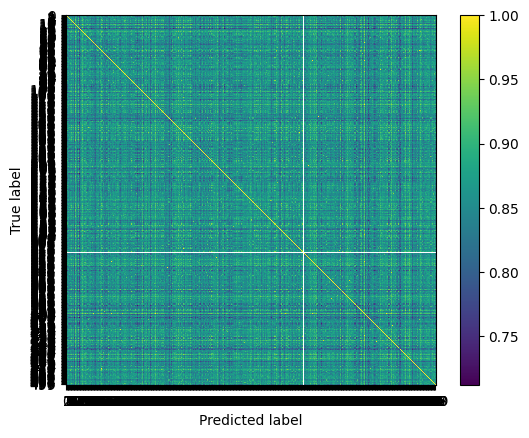

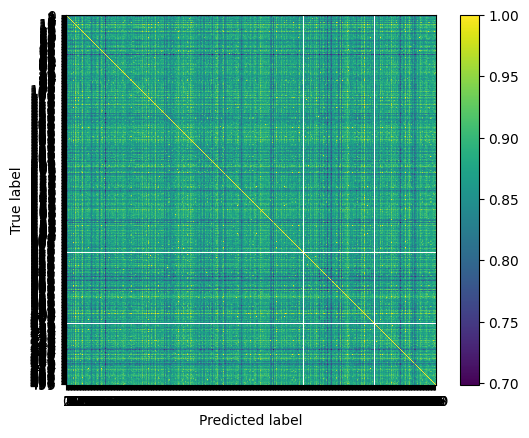

In [106]:
import pylab

disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,0], display_labels = None)
disp.plot(include_values = False)
pylab.show()
disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,1], display_labels = None)
disp.plot(include_values = False)
pylab.show()
disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,2], display_labels = None)
disp.plot(include_values = False)
pylab.show()
disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,3], display_labels = None)
disp.plot(include_values = False)
pylab.show()
disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,4], display_labels = None)
disp.plot(include_values = False)
pylab.show()

In [107]:
text_similarities_matrix = np.nan_to_num(text_similarities_matrix, nan = 1e-3)

## Кластеризация (?)

In [108]:
true_clusters = red_udcc

In [109]:
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,0])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,1])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,2])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,3])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,4])
print(bcb_clust(clustering.labels_, true_clusters))

(0.2589098478323281, 0.6885583446890123, 0.3498725576340246)
(0.2566264196260077, 0.4994594909448454, 0.3309755822715285)
(0.2566264196260077, 0.4994594909448454, 0.3309755822715285)
(0.40428170472603586, 0.4782743211974491, 0.4228787900110484)
(0.3258503770890587, 0.422132144861088, 0.35969128575091486)


In [110]:
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,0])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,1])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,2])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,3])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,4])
print(bcb_clust(clustering.labels_, true_clusters))

(0.2578019521345666, 0.5654144529767932, 0.3339053816663514)
(0.2566264196260077, 0.4994594909448454, 0.3309755822715285)
(0.2597480520825245, 0.5279801401157481, 0.32989776633163226)
(0.40428170472603586, 0.4782743211974491, 0.4228787900110484)
(0.3258503770890587, 0.422132144861088, 0.35969128575091486)


In [111]:
import random
import numpy as np

def random_segmentation(true_seg):
    claster_count = len(np.unique(true_seg))
    random_clasters = []
    for _ in true_seg:
        random_clasters.append(random.choice(range(claster_count)))
    return random_clasters

bcb_clust(random_segmentation(true_clusters), true_clusters)

(0.2596353534387972, 0.25676566255724603, 0.25689515060682433)

## Оценка